In [2]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time

In [3]:
# frank1d
import frank
from frank.geometry import FixedGeometry, SourceGeometry, FitGeometryGaussian
from frank.radial_fitters import FrankFitter
from frank.utilities import UVDataBinner
from frank.utilities import convolve_profile

In [4]:
# import the frank2d directory
current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d.frank2d import Frank2D 
from frank2d.geometry import Geometry
from frank2d.constants import rad_to_arcsec
from frank2d.plot import Plot
from frank2d.fitting import IterativeSolverMethod

In [5]:
from scipy.special import j0
from scipy.stats import binned_statistic

In [6]:
from scipy.optimize import curve_fit

### Functions

In [7]:
def gauss(r, sigma):
    return np.exp(-0.5*((r-rout/2.)/sigma)**2)

### Load data

In [8]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [9]:
data = Elias27

# UVtable
dir = "../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

# Load data
file = np.load(data_file)
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

In [10]:
# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [11]:
geom_f2d = Geometry(inc, pa, dra, ddec)
geom_Ring = geom_f2d

### Create the ring in uv-space

In [44]:
# Deprojection
du, dv, _ = geom_f2d.deproject(u, v)
dbaseline = np.hypot(du, dv)

baseline = np.hypot(u, v)

In [45]:
baseline_ring = baseline
u_ring = u
v_ring = v

In [46]:
Re_ring = np.median(Re[np.where(baseline_ring<3e4)])*np.real(j0(2.*np.pi*(rout/rad_to_arcsec/2.)*baseline_ring))

In [47]:
Imag_ring = np.zeros(len(Re))
Vis_ring = Re_ring + Imag_ring*1j

In [48]:
uvtable = {'u': u_ring, 'v': v_ring, 'vis': Vis_ring, 'weights': Weights}

### Frank2D

In [211]:
N = 4000

In [212]:
frank2d = Frank2D(N, rout, geom_f2d)

In [213]:
kernel_params =  {'m': -2, 'c': 10**8, 'l': 1e4}

Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.05  min |  3.17 seconds
--> time = 0.05  min |  3.18 seconds
Solving linear system...
         * rtol: 1e-07
         * final tolerance: 3.332571737028627
Final tolerance :  3.332571737028627
.... iteration:  0
                        -> actual tol:  33325717.370286275 vs  3.332571737028627
.... iteration:  1
                        -> actual tol:  66348.87740533026 vs  3.332571737028627
.... iteration:  2
                        -> actual tol:  163.59305578657657 vs  3.332571737028627
.... iteration:  3
                        -> actual tol:  0.45087486377363806 vs  3.332571737028627
 --------------------------------------> CGM converged in  3  iterations with tol  0.45087486377363806


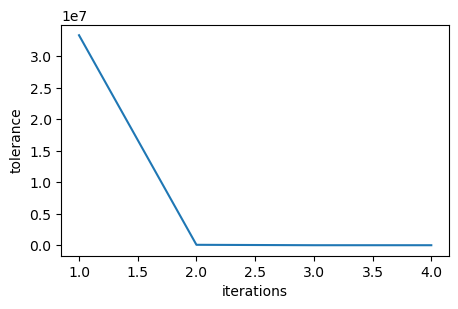

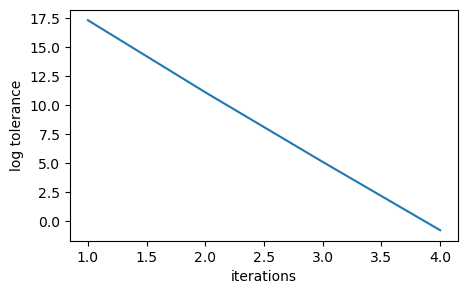

--> time = 0.00  min |  0.22 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   False
Building full visibility model...
--> times building full visibility model = 4.64  min |  278.14 seconds


In [214]:
frank2d.process_vis(uvtable)
frank2d.fit(kernel_params = kernel_params, rtol = 1e-7 )

### Best

In [19]:
frank2d.search_MAP()

Fitting the visibilities with Frank2D with 2DFT...


  + Time to set up the matrices: 59.52 seconds
Setting the initial guess...
Optimizing the posterior...


In [20]:
best = frank2d.MAP

{'m': -1.9998528176723587, 'c': 88290131.06146702, 'l': 17595.853929731642}

### run a new Frankobject

In [53]:
best = {'m': -1.9998528176723587, 'c': 88290131.06146702, 'l': 17595.853929731642}

In [54]:
N = 1500

In [55]:
frank2d2 = Frank2D(N, rout, geom_f2d)

Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.13  min |  7.67 seconds
--> time = 0.13  min |  7.75 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 0.33325717370286273
Final tolerance :  0.33325717370286273
.... iteration:  0
                        -> actual tol:  33325717.370286275 vs  0.33325717370286273
.... iteration:  1
                        -> actual tol:  4238668.855032192 vs  0.33325717370286273
.... iteration:  2
                        -> actual tol:  1695114.7577817615 vs  0.33325717370286273
.... iteration:  3
                        -> actual tol:  803602.074635273 vs  0.33325717370286273
.... iteration:  4
                        -> actual tol:  441405.50790021894 vs  0.33325717370286273
.... iteration:  5
                        -> actual tol:  266610.50910069013 vs  0.33325717370286273
.... iteration:  6
                        -> actual tol:  155368.15227111027 vs  0.3332

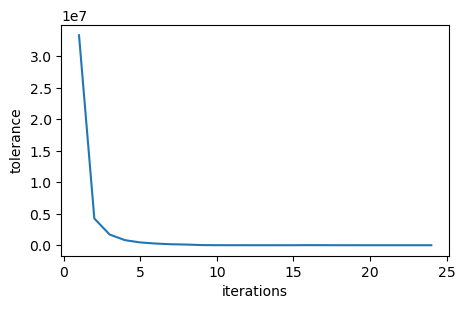

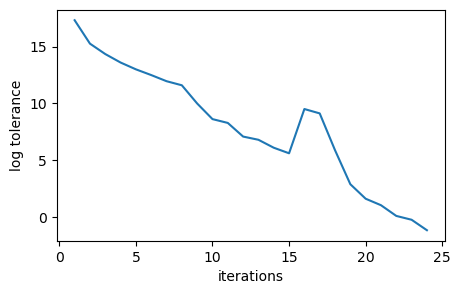

--> time = 0.04  min |  2.26 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   False
Building full visibility model...
--> times building full visibility model = 0.89  min |  53.11 seconds


In [56]:
frank2d2.fit(data= uvtable, kernel_params = best, rtol = 1e-8)

### Plot

In [57]:
Plot_ = Plot(frank2d2, geom_f2d)

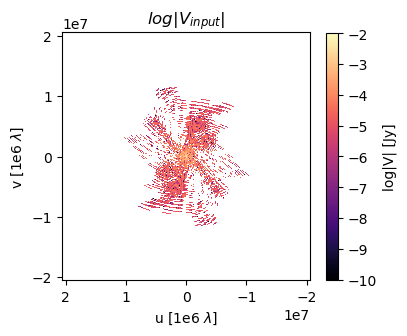

In [58]:
Plot_.visibility(fig_size = 4, kind = 'input',  title= r'$log|V_{input}|$')

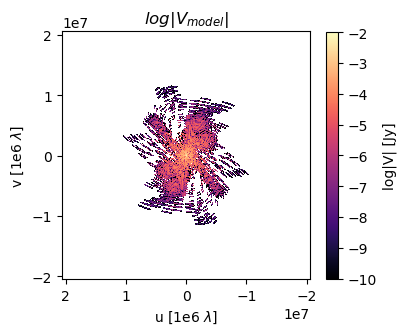

In [59]:
Plot_.visibility(fig_size = 4, title= r'$log|V_{model}|$')

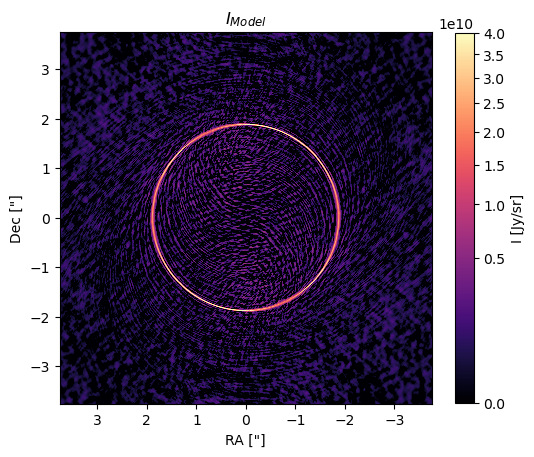

In [60]:
Plot_.intensity(fig_size = 6, phase_shift=True)

### FWHM

In [216]:
# deproject
x_model_1d, y_model_1d = geom_f2d.deproject_xy(Plot_._x_model_1d, Plot_._y_model_1d)
x_model, y_model = Plot_._x_model, Plot_._y_model

In [217]:
I = Plot_._int_model

In [215]:
r_ = np.unique(np.hypot(x_model_1d, y_model_1d))
bins_f2d = 2*N
r = np.linspace(r_.min(), r_.max(), bins_f2d)
edges = Plot_.edges(r)

In [218]:
r_f2d, I_f2d = Plot_.get_profile(x_model, y_model, I, bins = edges)

In [219]:
I_f2d = np.nan_to_num(I_f2d, nan=0)

In [220]:
popt_frank2d, cov = curve_fit(gauss, r_f2d, I_f2d/np.max(I_f2d), p0=[0.09])
FWHM_frank2d = popt_frank2d[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_f2d = np.sqrt(cov[0][0])* 2. *np.sqrt(2.*np.log(2.)) 

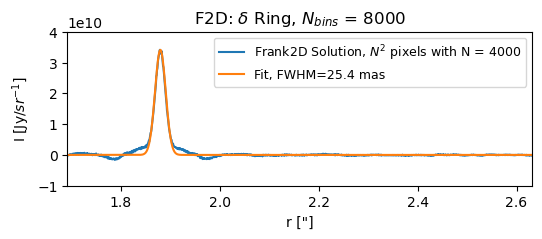

In [221]:
plt.close()
plt.figure(figsize=(6,2))
plt.plot(r_f2d, I_f2d, color='C0',label= r'Frank2D Solution, $N^{2}$ pixels with N = ' + str(N))
plt.plot(r_f2d, gauss(r_f2d, *popt_frank2d)*np.max(I_f2d), color='C1', label='Fit, FWHM=%.1f mas'%(FWHM_frank2d*1000))
plt.ylabel(r'I [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(0.45*rout, 0.7*rout)
plt.ylim(-1e10, 4e10)
plt.title(r'F2D: $\delta$ Ring, $N_{bins}$ = '+ str(bins_f2d))
plt.legend(loc='best', fontsize = 9)

In [68]:
print ('FWHM=', FWHM_frank2d, '+/-', Error_FWHM_f2d, 'arcsec')   

FWHM= 0.025462828371831683 +/- 0.00011924414429835927 arcsec


In [167]:
res_f2d_before = x_model_1d[1] - x_model_1d[0]
res_f2d_after = r_f2d[1] - r_f2d[0]
print(res_f2d_before, res_f2d_after)

0.003555709736589474 0.001920886180348954


### Frank1D

In [12]:
 # load data
u_f1d, v_f1d, Re_f1d, Imag_f1d, Weights_f1d = u, v, Re, Im, Weights
Vis_f1d = Re_f1d + Imag_f1d*1j

In [13]:
u_f1d_d, v_f1d_d, _ = geom_f2d.deproject(u_f1d, v_f1d)
dbaseline_f1d = np.hypot(u_f1d_d, v_f1d_d)
baseline_f1d = np.hypot(u_f1d, v_f1d)

In [14]:
baseline_ring_f1d = dbaseline_f1d

In [15]:
Re_ring = np.median(Re_f1d[np.where(baseline_ring_f1d<3e4)])*np.real(j0(2.*np.pi*(rout/rad_to_arcsec/2.)*baseline_ring_f1d))

In [16]:
Imag_ring = np.zeros(len(Re_ring))
Vis_f1d = Re_ring + Imag_ring*1j

In [17]:
rout

3.76

In [126]:
# Frank 1D parameters
n_pts = 1500
alpha = 1.25
w_smooth = 1e-1
r_out = rout

geom = SourceGeometry(inc= inc, PA= pa, dRA= dra, dDec= ddec)
FF = FrankFitter(r_out, n_pts, geom, alpha = alpha, weights_smooth = w_smooth)
sol = FF.fit(u_f1d, v_f1d, Vis_f1d, Weights_f1d)

In [181]:
r_f1d = sol.r
I_f1d = sol.mean

In [182]:
#Plot_2 = Plot(frank2d2, geom_f2d)
#r_ = np.unique(np.hypot(x_model_1d, y_model_1d))

#r_ = r_f1d
bins_f1d = 1500
#r = np.linspace(r_.min(), r_.max(), bins_f1d)
#edges = Plot_.edges(r)

#r_f1d, I_f1d = Plot_.get_profile(sol.r, sol.r, sol.mean, bins = edges, fit_1d = True)

#I_f1d = np.nan_to_num(I_f1d, nan=0)

In [183]:
res_f1d_before = sol.r[1] - sol.r[0]
res_f1d_after  = r_f1d[1] - r_f1d[0]
print('F1D Resolution before binning:', res_f1d_before, 'after binning:', res_f1d_after)

F1D Resolution before binning: 0.002484407766997341 after binning: 0.002484407766997341


In [184]:
popt_frank1d, cov_frank1d = curve_fit(gauss, r_f1d, I_f1d/np.max(I_f1d), p0=[0.02])
FWHM_frank1d = popt_frank1d[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_frank1d = np.sqrt(cov_frank1d[0][0])* 2. *np.sqrt(2.*np.log(2.))

In [185]:
print ('FWHM=', FWHM_frank1d, '+/-', Error_FWHM_frank1d, 'arcsec')   

FWHM= 0.025982916602536033 +/- 0.00010706491100308832 arcsec


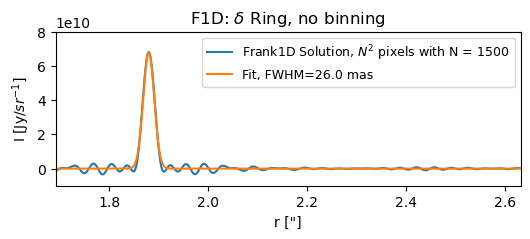

In [210]:
plt.close()
plt.figure(figsize=(6,2))
plt.plot(r_f1d, I_f1d, color='C0',label= r'Frank1D Solution, $N^{2}$ pixels with N = ' + str(n_pts))
plt.plot(r_f1d, gauss(r_f1d, *popt_frank1d)*np.max(sol.mean), color='C1', label='Fit, FWHM=%.1f mas'%(FWHM_frank1d*1000))
plt.ylabel(r'I [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(0.45*rout, 0.7*rout)
plt.ylim(-1e10, 8e10)
plt.title(r'F1D: $\delta$ Ring, no binning')# $N_{bins}$ = '+ str(bins))
plt.legend(loc='best', fontsize = 9)

In [2]:
plt.figure(figsize=(4,2))
plt.plot(r_f1d, I_f1d,label= r'F1D, $N^{2}$ pixels (N = ' + str(n_pts) + '), bins =' + 'no bins' + ', FWHM=%.1f mas'%(FWHM_frank1d*1000))
plt.plot(r_f2d, I_f2d, label= r'F2D, $N^{2}$ pixels (N = ' + str(N) + '), bins ='+  str(bins_f2d) + ', FWHM=%.1f mas'%(FWHM_frank2d*1000))
plt.ylabel(r'I [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(0.45*rout, 0.7*rout)
plt.ylim(-1e10, 11e10)
plt.title('Radial intensity profile of delta ring')
plt.legend(loc='best', fontsize = 6)

NameError: name 'plt' is not defined

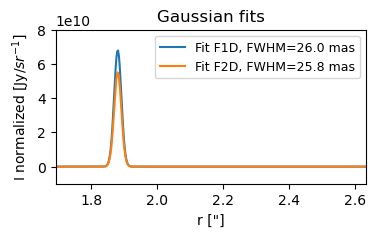

In [209]:
plt.close()
plt.figure(figsize=(4,2))
plt.plot(sol.r, gauss(sol.r, *popt_frank1d)*np.max(sol.mean), label='Fit F1D, FWHM=%.1f mas'%(FWHM_frank1d*1000))
plt.plot(r, gauss(r, *popt_frank2d)*np.max(I), label='Fit F2D, FWHM=%.1f mas'%(FWHM_frank2d*1000))
plt.ylabel(r'I normalized [Jy/$sr^{-1}$]')
plt.xlabel('r ["]')
plt.xlim(0.45*rout, 0.7*rout)
plt.ylim(-1e10, 8e10)
plt.title('Gaussian fits')
plt.legend(loc='best', fontsize = 9)

#### understanding the differences

### Convolve to the f2d beam

In [143]:
sigma_final = np.sqrt(FWHM_frank2d**2 - FWHM_frank1d**2)
sigma_final

0.01795838309477733

In [144]:
beam_1mm = {'bmaj':sigma_final, 'bmin':sigma_final, 'beam_pa':geom.PA}
convolved_frank1d = convolve_profile(r_f1d, I_f1d, geom.inc, geom.PA, beam_1mm)

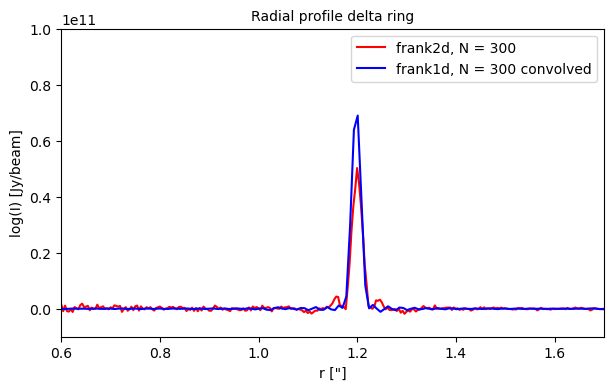

In [145]:
plt.figure(figsize=(7, 4))
plt.plot(r_f2d, I_f2d, "red", label=r'frank2d' + ', N = ' +str(n_pts))
plt.plot(r_f1d, convolved_frank1d, "blue", label=r'frank1d' + ', N = ' +str(N)+ ' convolved')
plt.title(r'Radial profile delta ring', size=10)
plt.ylabel("log(I) [Jy/beam]", size=10)
plt.xlabel('r ["]', size=10)
plt.xlim(0.6, 1.7)
plt.ylim(-1e10, 10e10)
plt.legend(fontsize=10)
plt.show()

In [69]:
popt_frank1d_conv, cov_frank1d_conv = curve_fit(gauss, r_f1d, convolved_frank1d/np.max(convolved_frank1d), p0=[0.009])
FWHM_frank1d_conv = popt_frank1d_conv[0]* 2. *np.sqrt(2.*np.log(2.))
Error_FWHM_frank1d_conv = np.sqrt(cov_frank1d[0][0])* 2. *np.sqrt(2.*np.log(2.))

In [70]:
FWHM_frank1d_conv

0.0225764452262478

### Trying with real disk

In [11]:
u, v, Re, Im, Weights = file['u'], file['v'], file['Re'], file['Im'], file['w']
Vis = Re + Im*1j

In [12]:
N = 300
best = {'m': -1.011407337728121, 'c': 222.9257843669846, 'l': 46452.74921193543}

In [13]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [14]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

Setting gridded data...
Setting GP Kernel Wendland...
Creating sparse linear system...
--> time kernel = 0.06  min |  3.58 seconds
--> time = 0.06  min |  3.73 seconds
Solving linear system...
         * rtol: 1e-08
         * final tolerance: 0.5684907757598309
Final tolerance :  0.5684907757598309
.... iteration:  0
                        -> actual tol:  56849077.575983085 vs  0.5684907757598309
.... iteration:  1
                        -> actual tol:  4684503.981285397 vs  0.5684907757598309
.... iteration:  2
                        -> actual tol:  4477417.699154122 vs  0.5684907757598309
.... iteration:  3
                        -> actual tol:  5226318.801233864 vs  0.5684907757598309
.... iteration:  4
                        -> actual tol:  10665233.152736386 vs  0.5684907757598309
.... iteration:  5
                        -> actual tol:  4068082.8731171307 vs  0.5684907757598309
.... iteration:  6
                        -> actual tol:  2644989.043837369 vs  0.5684907757598

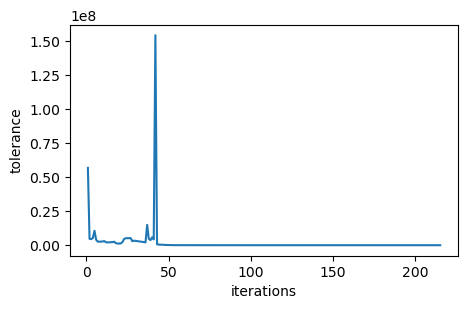

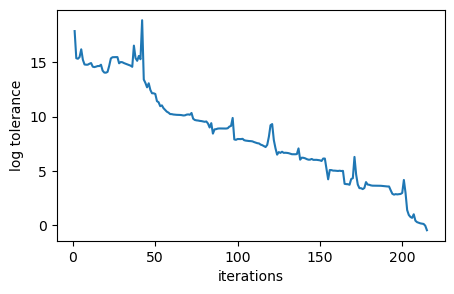

--> time = 0.25  min |  14.74 seconds
               ---> CGM converged?   True
                    ---> Fit correctly?   True
                     !!!!  Sucess..  !!!!
Building full visibility model...
--> times building full visibility model = 0.08  min |  4.97 seconds
F2D model in 30.07 seconds.


In [15]:
start_time = time.time()


frank2d.fit(data = uvtable, kernel_params = best, rtol = 1e-8 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time):.2f} seconds.")

In [16]:
FWHM_frank2d = 0.0268
FWHM_frank1d = 0.027

In [17]:
Plot_ = Plot(frank2d, geom)

In [18]:
from astropy.io import fits
dir =  "/Users/mariajmelladot/Desktop/Frank2D/data/fits/"
disk = disk_name + '_continuum.fits'

fits_name = dir + disk

In [19]:
Plot_.set_fits_file(fits_name)

In [21]:
sol_f1d = frank2d.frank1d(uvtable, alpha=1.25, w_smooth=1e-1, n_pts=500, rout=rout, geom=geom)

Performing 1D Frank fit...

$\alpha$ =  1.25  and $w_{smooth}$ =  0.1

N =  500  and $R_{max}$ =  3.76


In [21]:
Plot_.set_f1d_solution(sol_f1d)

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
FWHM for frank2d: 0.022905863089907247 arcsec
-> Final beam to convolve with: 0.03059095415189107 x 0.028063616248335515 arcsec
FWHM for frank1d: 0.011191120375380921 arcsec
-> Final beam to convolve with: 0.0365409888284432 x 0.034452923614276196 arcsec


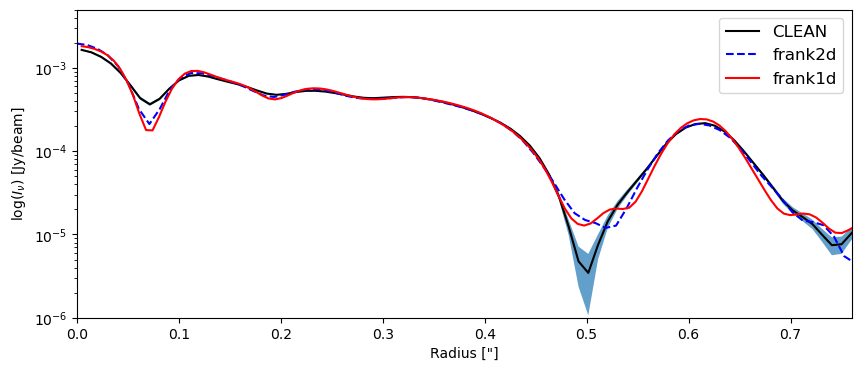

In [22]:
Plot_.intensity_profile(   clean = True, frank1d = True,
                            resol_f2d = FWHM_frank2d, resol_f1d = FWHM_frank1d
                        )

UnboundLocalError: cannot access local variable 'y_lims_sr' where it is not associated with a value

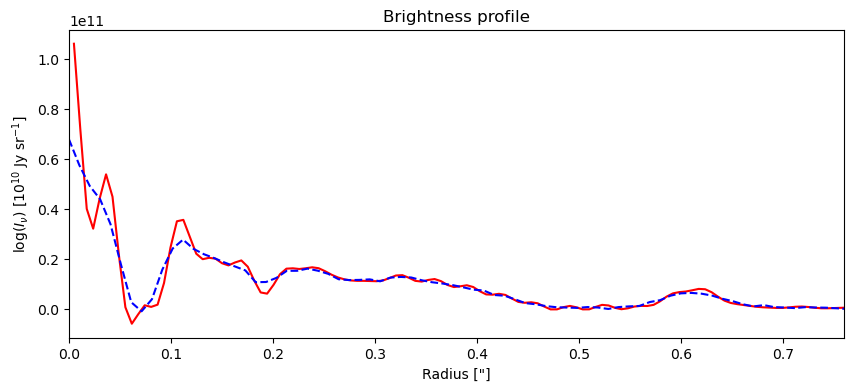

In [24]:
Plot_.intensity_profile(   clean = False, frank1d = True,
                            resol_f2d = FWHM_frank2d, resol_f1d = FWHM_frank1d, 
                            y_lims = (1e8, 1e12)
                        )